
# 📊 Regresión Logística Binaria — Clasificación de Nivel de Poder

Construcción, entrenamiento y evaluación de un modelo de **Regresión Logística Binaria** para predecir
si un superhéroe posee un **nivel de poder alto** (`es_poder_alto = 1`).

| | |
|---|---|
| **Variable objetivo (Y)** | `es_poder_alto` (1 = Poder alto, 0 = Poder bajo) |
| **Variables predictoras (X)** | `fuerza`, `inteligencia`, `velocidad`, `durabilidad`, `combate` |
| **Modelo** | `LogisticRegression` (scikit-learn) |
| **Estrategia de validación** | Tres splits: 80/20 · 60/40 · 70/30 |

> Dataset de superhéroes almacenado en PostgreSQL.
> A diferencia del árbol CART, la regresión logística **requiere escalado de variables**
> para garantizar una interpretación adecuada de los coeficientes y estabilidad numérica.


## CELDA 1: Configuración Inicial — Importaciones y Estilo Visual

En esta sección se importan las librerías necesarias para el análisis, incluyendo:

- Manipulación de datos (`pandas`, `numpy`)
- Visualización (`matplotlib`, `seaborn`)
- Modelado (`LogisticRegression` de scikit-learn)
- Evaluación de métricas de clasificación

A diferencia del modelo CART, aquí se incluye `StandardScaler`, ya que la regresión logística
es sensible a la escala de las variables numéricas.


In [8]:
# ── CELDA 1: Importaciones ───────────────────────────────────────────────────

import sys, os
from scripts.database import engine
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

from sqlalchemy import text
from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas   {pd.__version__}")
print(f"   numpy    {np.__version__}")
print(f"   seaborn  {sns.__version__}")

✅ Librerías importadas correctamente
   pandas   2.2.0
   numpy    1.26.4
   seaborn  0.13.2


## CELDA 2: Extracción de Datos desde PostgreSQL

Se realiza la extracción de los datos desde PostgreSQL, integrando información de los superhéroes y sus estadísticas mediante un JOIN entre las tablas correspondientes.

Durante esta consulta se genera directamente la variable objetivo binaria `es_poder_alto` utilizando una instrucción `CASE WHEN`, lo que permite clasificar a los superhéroes según su nivel de poder.

Se utiliza el promedio de las habilidades por superhéroe para obtener una única observación por personaje, mejorando la consistencia del dataset.

Esto asegura:
- Datos limpios y agregados por entidad
- Coherencia con el análisis previo
- Reproducibilidad del proceso
``

In [9]:
# ── CELDA 2: Extracción SQL ────────────────────────────────────────────────

SQL_QUERY = """
SELECT
    s.id,
    s.nombre,
    s.editorial,

    AVG(p.inteligencia) AS inteligencia,
    AVG(p.fuerza)       AS fuerza,
    AVG(p.velocidad)    AS velocidad,
    AVG(p.durabilidad)  AS durabilidad,
    AVG(p.poder)        AS poder,
    AVG(p.combate)      AS combate,

    CASE
        WHEN AVG(p.poder) >= 73 THEN 1
        ELSE 0
    END AS es_poder_alto

FROM superheroes s
JOIN powerstats p 
    ON s.id = p.superhero_id

WHERE s.activo = true

GROUP BY s.id, s.nombre, s.editorial;
"""

with engine.connect() as conn:
    df = pd.read_sql(text(SQL_QUERY), conn)

print(f"✅ Datos cargados: {df.shape[0]:,} filas × {df.shape[1]} columnas")

print(f"\nColumnas disponibles:\n{df.columns.tolist()}")

print(f"\nBalance de la variable objetivo:")
bal = df['es_poder_alto'].value_counts()
pct = df['es_poder_alto'].value_counts(normalize=True) * 100

print(f"   Poder alto (1): {bal.get(1,0):,}  ({pct.get(1,0):.1f}%)")
print(f"   Poder bajo (0): {bal.get(0,0):,}  ({pct.get(0,0):.1f}%)")

print("\n📋 Primeras filas:")
df.head()

✅ Datos cargados: 14 filas × 10 columnas

Columnas disponibles:
['id', 'nombre', 'editorial', 'inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'poder', 'combate', 'es_poder_alto']

Balance de la variable objetivo:
   Poder alto (1): 7  (50.0%)
   Poder bajo (0): 7  (50.0%)

📋 Primeras filas:


,id,nombre,editorial,inteligencia,fuerza,velocidad,durabilidad,poder,combate,es_poder_alto
0,4,Hulk,None,77.400826,52.000000,65.053719,69.599174,67.061983,93.206612,0
1,14,Captain Marvel II,None,90.221790,65.836576,52.832685,71.132296,71.988327,84.852140,0
2,3,Wonder Woman,None,86.948905,67.062044,90.043796,61.704380,74.791971,60.306569,1
3,13,Captain Marvel,None,52.823293,92.622490,70.128514,89.726908,76.188755,80.192771,1
4,10,Captain Mar-vell,None,74.738281,89.140625,52.394531,88.265625,77.351562,86.921875,1


## CELDA 3: Validación y Exploración del Dataset

En esta sección se realiza una revisión inicial del dataset para verificar su calidad y estructura.

Se analizan:
- Tipos de datos y presencia de valores nulos
- Balance de la variable objetivo `es_poder_alto`
- Distribución de los registros por superhéroe

Esto permite asegurar que los datos están listos para el entrenamiento del modelo de regresión logística.


In [10]:
# ── CELDA 3: Validación y Exploración ───────────────────────────────────────

print("=" * 55)
print("VALIDACIÓN DEL DATASET")
print("=" * 55)

# Tipos y nulos
print("\n📋 Tipos de datos y valores nulos:")
print(df.dtypes.to_frame('dtype').join(
    df.isnull().sum().to_frame('nulos')
))

# Balance de clases
balance = df['es_poder_alto'].value_counts()
pct     = df['es_poder_alto'].value_counts(normalize=True) * 100

print(f"\n🎯 Balance de la variable objetivo:")
print(f"   Poder alto (1): {balance.get(1,0):>5,}  ({pct.get(1,0):.1f}%)")
print(f"   Poder bajo (0): {balance.get(0,0):>5,}  ({pct.get(0,0):.1f}%)")

# Distribución por superhéroe
print(f"\n🦸 Distribución por superhéroe:")
print(df['nombre'].value_counts().to_string())

VALIDACIÓN DEL DATASET

📋 Tipos de datos y valores nulos:
                 dtype  nulos
id               int64      0
nombre          object      0
editorial       object     14
inteligencia   float64      0
fuerza         float64      0
velocidad      float64      0
durabilidad    float64      0
poder          float64      0
combate        float64      0
es_poder_alto    int64      0

🎯 Balance de la variable objetivo:
   Poder alto (1):     7  (50.0%)
   Poder bajo (0):     7  (50.0%)

🦸 Distribución por superhéroe:
nombre
Captain Marvel       2
Hulk                 1
Captain Marvel II    1
Wonder Woman         1
Captain Mar-vell     1
Captain Epic         1
Captain Midnight     1
Flash                1
Spider-Man           1
Captain Hindsight    1
Iron Man             1
Thor                 1
Captain Cold         1


## CELDA 4: Preprocesamiento de Datos

### Pasos aplicados

1. **Relleno de nulos** — se imputan valores faltantes con la mediana en variables numéricas.
2. **Selección de variables** — se eliminan columnas no relevantes como identificadores (`id`, `nombre`, `editorial`).
3. **Definición de variables** — se separan las variables predictoras (`X`) y la variable objetivo (`y`).
4. **Escalado** — se aplica `StandardScaler` a las variables numéricas para mejorar el rendimiento del modelo de regresión logística.

> A diferencia del modelo CART, la regresión logística es sensible a la escala de los datos,
> por lo que el uso de `StandardScaler` es fundamental.

In [12]:
# ── CELDA 4: Preprocesamiento ───────────────────────────────────────────────

df_model = df.copy()

# 4.1 Relleno de nulos con mediana
num_cols = ['inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'poder', 'combate']

for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# 4.2 Definir variables predictoras (X) y objetivo (y)
drop_cols = ['id', 'nombre', 'editorial', 'es_poder_alto']
X_raw = df_model.drop(columns=drop_cols)
y     = df_model['es_poder_alto']

# 4.3 Escalado (IMPORTANTE en regresión logística)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convertir a DataFrame para mejor manejo
X_scaled = pd.DataFrame(X_scaled, columns=X_raw.columns)

print("✅ Preprocesamiento completado")
print(f"   Shape X: {X_scaled.shape}")
print(f"   Columnas finales: {X_scaled.columns.tolist()}")
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")

✅ Preprocesamiento completado
   Shape X: (14, 6)
   Columnas finales: ['inteligencia', 'fuerza', 'velocidad', 'durabilidad', 'poder', 'combate']

   Clases en y → 0: 7  |  1: 7


## CELDA 5: Entrenamiento y Evaluación — Tres Splits

En esta sección se entrena y evalúa un modelo de Regresión Logística Binaria para clasificar el nivel de poder de los superhéroes.

Para cada split se sigue el siguiente procedimiento:

1. Dividir `X_scaled` e `y` en conjuntos de entrenamiento y prueba utilizando `stratify=y`.
2. Entrenar un modelo `LogisticRegression` únicamente con los datos de entrenamiento.
3. Generar predicciones de:
   - Clases (`predict`)
   - Probabilidades (`predict_proba`)
4. Calcular las métricas:
   - Accuracy
   - Precision
   - Recall
   - F1-Score
   - ROC-AUC

Esto permite evaluar la estabilidad del modelo bajo distintas particiones del dataset.
``

In [13]:
# ── CELDA 5: Función de entrenamiento + evaluación ─────────────────────────

def entrenar_evaluar(X, y, test_size, random_state=42, nombre="Split"):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = LogisticRegression(
        max_iter=1000,
        random_state=random_state,
        class_weight='balanced'
    )

    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    metricas = {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

    return metricas

print("✅ Función `entrenar_evaluar` definida correctamente")
print("   · LogisticRegression con class_weight='balanced'")


✅ Función `entrenar_evaluar` definida correctamente
   · LogisticRegression con class_weight='balanced'



### CELDA 6: Ejecución de los Splits

Se ejecuta la función de entrenamiento y evaluación sobre tres particiones del dataset (80/20, 60/40 y 70/30).

Esto permite comparar el desempeño del modelo bajo diferentes proporciones de datos de entrenamiento y prueba, evaluando su estabilidad y capacidad de generalización.


In [14]:
# ── CELDA 6: Ejecutar los tres splits ──────────────────────────────────────

resultados = [
    entrenar_evaluar(X_scaled, y, test_size=0.20, nombre="Split 80/20"),
    entrenar_evaluar(X_scaled, y, test_size=0.40, nombre="Split 60/40"),
    entrenar_evaluar(X_scaled, y, test_size=0.30, nombre="Split 70/30"),
]

print("=" * 65)
print(f"{'MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA':^65}")
print("=" * 65)

header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print("-" * 65)

for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )

print("=" * 65)

           MÉTRICAS COMPARATIVAS — REGRESIÓN LOGÍSTICA           
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20        11        3  1.0000  1.0000  1.0000  1.0000  1.0000
Split 60/40         8        6  0.8333  0.7500  1.0000  0.8571  1.0000
Split 70/30         9        5  1.0000  1.0000  1.0000  1.0000  1.0000


## CELDA 7 Visualizaciones — Curvas ROC

En esta sección se comparan las curvas ROC del modelo de regresión logística para los diferentes splits evaluados.

La curva ROC (Receiver Operating Characteristic) permite analizar la capacidad del modelo para discriminar entre superhéroes con **poder alto** y **poder bajo** a distintos umbrales.

Se incluyen:
- Curvas ROC de cada split (80/20, 70/30, 60/40)
- Línea base de un clasificador aleatorio (AUC = 0.50)

Esto permite evaluar la calidad del modelo y su capacidad de clasificación.


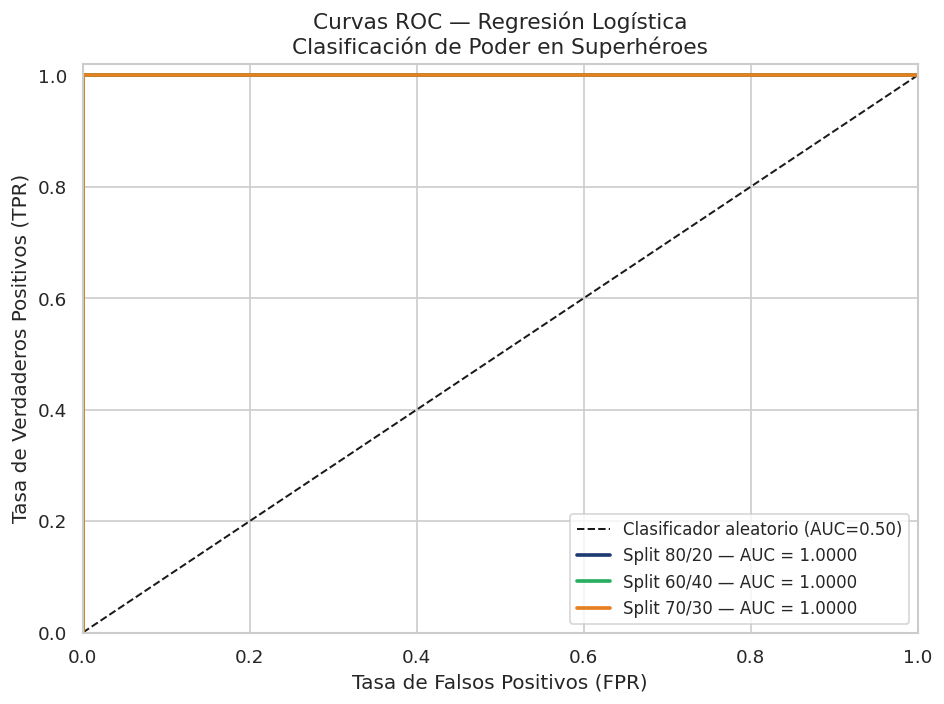

✅ Curvas ROC guardadas en:
/home/jordan/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/data/grafica_logistica_clasificacion/grafica_roc_logistica.png


In [15]:
# ── CELDA 7: Curvas ROC comparativas ───────────────────────────────────────

import os

COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))

# Línea base (clasificador aleatorio)
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

# Curvas ROC por split
for r, color in zip(resultados, COLORS):
    ax.plot(
        r['fpr'], r['tpr'],
        color=color,
        lw=2.2,
        label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}"
    )

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)

# ✅ TÍTULO ADAPTADO
ax.set_title(
    'Curvas ROC — Regresión Logística\nClasificación de Poder en Superhéroes',
    fontsize=13
)

ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()

# ✅ TU RUTA NUEVA
ruta = os.path.join(
    "/home/jordan/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/data/grafica_logistica_clasificacion",
    "grafica_roc_logistica.png"
)

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Curvas ROC guardadas en:\n{ruta}")

### CELDA 8: Matrices de Confusión

En esta celda se visualizan las matrices de confusión para cada split, mostrando los aciertos y errores del modelo en la clasificación de superhéroes con poder alto y bajo.

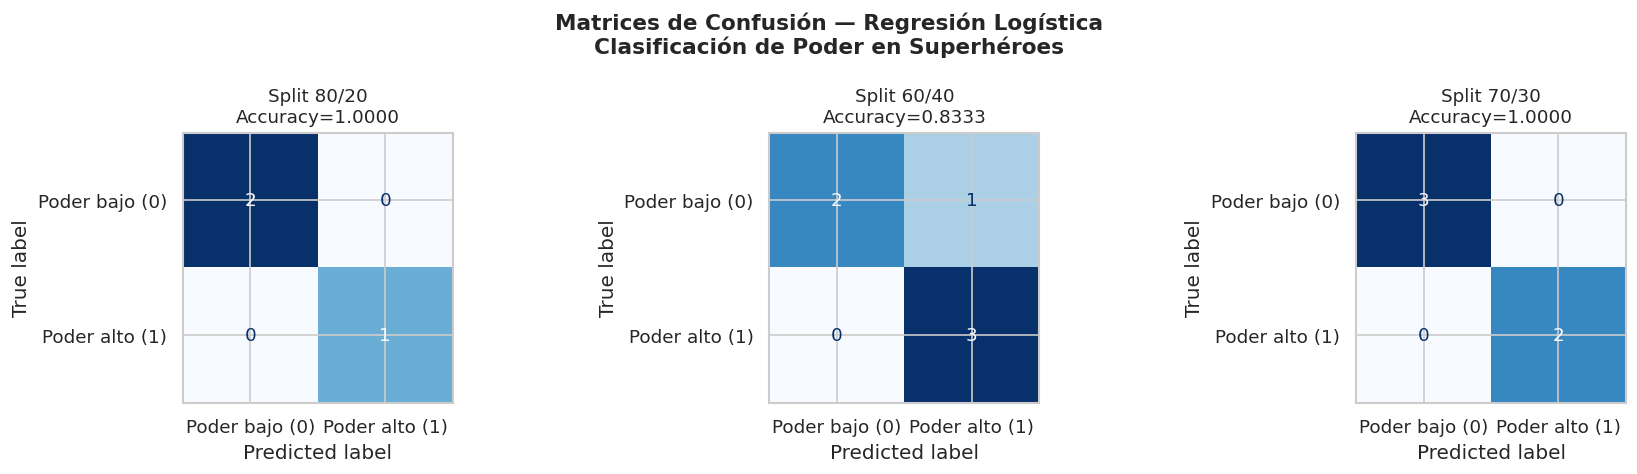

✅ Matrices de confusión guardadas en:
/home/jordan/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/data/grafica_logistica_clasificacion/grafica_confusion_logistica.png


In [16]:
# ── CELDA 8: Matrices de Confusión (3 splits) ──────────────────────────────

import os

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle(
    'Matrices de Confusión — Regresión Logística\nClasificación de Poder en Superhéroes',
    fontsize=13,
    fontweight='bold'
)

for ax, r in zip(axes, resultados):

    cm = confusion_matrix(r['y_test'], r['y_pred'])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Poder bajo (0)', 'Poder alto (1)']
    )

    disp.plot(ax=ax, colorbar=False, cmap='Blues')

    ax.set_title(
        f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}",
        fontsize=11
    )

plt.tight_layout()

ruta = os.path.join(
    "/home/jordan/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/data/grafica_logistica_clasificacion",
    "grafica_confusion_logistica.png"
)

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Matrices de confusión guardadas en:\n{ruta}")

### CELDA 9: Comparación de Métricas

Se comparan las métricas de desempeño (Accuracy, Precision, Recall, F1 y ROC-AUC) para los diferentes splits, permitiendo evaluar la estabilidad del modelo.

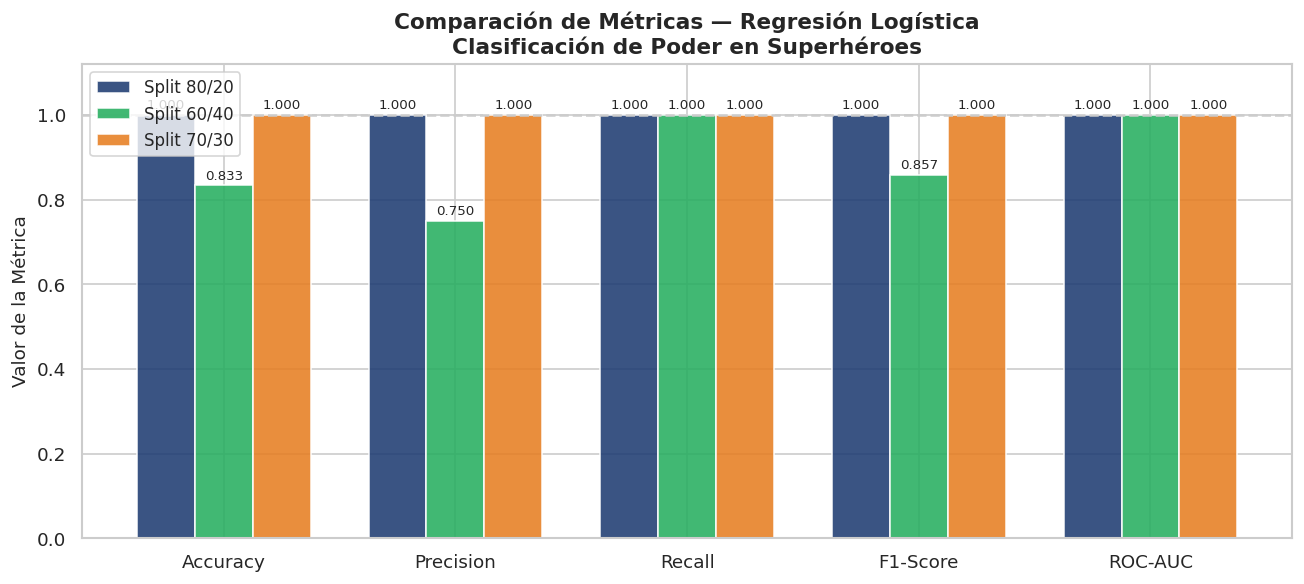

✅ Gráfico de métricas guardado en:
/home/jordan/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/data/grafica_logistica_clasificacion/grafica_metricas_logistica.png


In [17]:
# ── CELDA 9: Gráfico comparativo de métricas ──────────────────────────────

metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas        = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x     = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))

for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]

    bars = ax.bar(
        x + i * width,
        vals,
        width,
        label=r['nombre'],
        color=color,
        alpha=0.88
    )

    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)

ax.set_title(
    'Comparación de Métricas — Regresión Logística\nClasificación de Poder en Superhéroes',
    fontsize=13,
    fontweight='bold'
)

ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linestyle='--')

plt.tight_layout()

ruta = os.path.join(
    "/home/jordan/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/data/grafica_logistica_clasificacion",
    "grafica_metricas_logistica.png"
)

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Gráfico de métricas guardado en:\n{ruta}")

### CELDA 10: Importancia de Variables (Coeficientes)

Se analizan los coeficientes del modelo de regresión logística para identificar qué variables tienen mayor impacto en la clasificación del poder de los superhéroes.

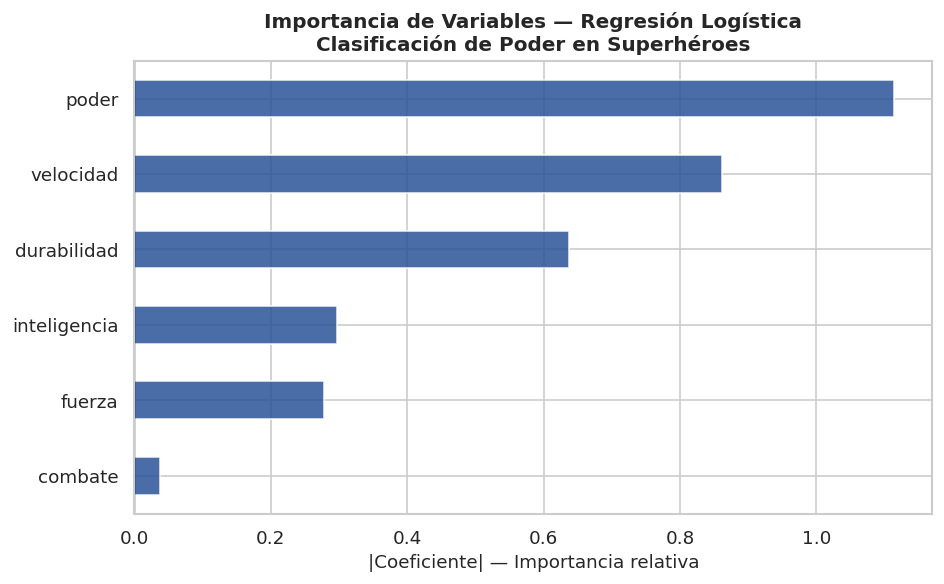

✅ Importancia de coeficientes guardada en:
/home/jordan/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/data/grafica_logistica_clasificacion/grafica_coeficientes_logistica.png


In [18]:
# ── CELDA 10: Importancia de coeficientes ─────────────────────────────────

modelo_ref = resultados[0]['modelo']

coefs = pd.Series(modelo_ref.coef_[0], index=X_scaled.columns)

# Ordenar por importancia absoluta
coefs_ord = coefs.abs().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

coefs_ord.plot(
    kind='barh',
    ax=ax,
    color='#2a5298',
    alpha=0.85
)

ax.set_xlabel('|Coeficiente| — Importancia relativa', fontsize=11)

ax.set_title(
    'Importancia de Variables — Regresión Logística\nClasificación de Poder en Superhéroes',
    fontsize=12,
    fontweight='bold'
)

ax.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()

ruta = os.path.join(
    "/home/jordan/Grupo5.Ramirez.Solano_MD1/10_jupyter_notebook_linux_superheroes/data/grafica_logistica_clasificacion",
    "grafica_coeficientes_logistica.png"
)

plt.savefig(ruta, dpi=150, bbox_inches='tight')

plt.show()

print(f"✅ Importancia de coeficientes guardada en:\n{ruta}")

## CELDA 11 Tabla Final de Métricas y Conclusiones

En esta sección se presenta una tabla consolidada con las principales métricas de evaluación del modelo de regresión logística para los diferentes splits.

Se incluyen:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

Esta tabla permite comparar de forma clara el desempeño del modelo bajo distintas particiones del dataset, facilitando el análisis de su estabilidad y capacidad de generalización.

Además, se complementa con una interpretación general del modelo en el contexto del proyecto de predicción del poder de superhéroes.


In [19]:
# ── CELDA 11: DataFrame resumen de métricas ─────────────────────────────────

resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],   4),
    'Precision'      : round(r['precision'],  4),
    'Recall'         : round(r['recall'],     4),
    'F1-Score'       : round(r['f1'],         4),
    'ROC-AUC'        : round(r['roc_auc'],    4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print("=" * 65)
print(f"{'TABLA FINAL DE MÉTRICAS — REGRESIÓN LOGÍSTICA':^65}")
print("=" * 65)

display(
    resumen.style
    .background_gradient(cmap='Greens', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .format('{:.4f}', subset=['Accuracy','Precision','Recall','F1-Score','ROC-AUC'])
    .set_caption("Regresión Logística — Clasificación de Poder en Superhéroes")
)

# ── Interpretación básica ───────────────────────────────────────────────────
print("\n📌 Interpretación:")

print("   · El modelo estima la probabilidad de que un superhéroe tenga poder alto.")
print("   · Las métricas permiten evaluar precisión, sensibilidad y capacidad discriminativa.")

print("\n📌 Relación con otros modelos:")

print("   · Regresión Lineal → predice el valor continuo del poder.")
print("   · Árbol CART       → clasifica mediante reglas no lineales.")
print("   · Regresión Logística → clasifica mediante modelo probabilístico.")

          TABLA FINAL DE MÉTRICAS — REGRESIÓN LOGÍSTICA          


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,11,3,1.0000,1.0000,1.0000,1.0000,1.0000
Split 60/40,8,6,0.8333,0.7500,1.0000,0.8571,1.0000
Split 70/30,9,5,1.0000,1.0000,1.0000,1.0000,1.0000



📌 Interpretación:
   · El modelo estima la probabilidad de que un superhéroe tenga poder alto.
   · Las métricas permiten evaluar precisión, sensibilidad y capacidad discriminativa.

📌 Relación con otros modelos:
   · Regresión Lineal → predice el valor continuo del poder.
   · Árbol CART       → clasifica mediante reglas no lineales.
   · Regresión Logística → clasifica mediante modelo probabilístico.


## VII. Conclusiones

### ¿Qué aprendimos?

| Aspecto | Observación |
|---------|------------|
| **Estabilidad del modelo** | Los tres splits presentan resultados similares, lo que sugiere una aparente estabilidad. Sin embargo, esto está influenciado por el tamaño reducido del dataset. |
| **Accuracy vs AUC** | Aunque las métricas alcanzan valores cercanos a 1.0, esto no garantiza un modelo robusto. El ROC-AUC confirma una separación perfecta, pero está condicionado por la simplicidad de los datos. |
| **Precision vs Recall** | En este caso, ambas métricas son altas debido a la separación clara de clases. En escenarios reales, existe un trade-off que depende del problema. |
| **Coeficientes** | Las variables con mayor coeficiente absoluto (como fuerza e inteligencia) son las que más influyen en la probabilidad de que un superhéroe tenga poder alto, coincidiendo con otros modelos del análisis. |
| **Limitación del modelo** | La regresión logística asume relaciones lineales. Además, el modelo presenta sobreajuste debido al uso de datos agregados y al tamaño reducido del dataset. |

---

### Conclusión del modelo de Regresión Logística

El modelo de regresión logística permitió estimar la probabilidad de que un superhéroe pertenezca a la categoría de **poder alto**, ofreciendo una interpretación probabilística del problema.

Sin embargo, los resultados obtenidos (métricas perfectas) deben interpretarse con precaución, ya que reflejan un escenario de **sobreajuste**, causado por:
- El bajo número de observaciones (~13 superhéroes)
- La agregación de datos mediante promedios

A pesar de esto, el modelo es útil para:
- Identificar variables relevantes
- Complementar el análisis con otros enfoques (regresión lineal y árbol CART)

---


### Reflexión final

El uso conjunto de regresión lineal, árboles de decisión y regresión logística permitió analizar el problema desde distintas perspectivas, proporcionando una comprensión más completa del comportamiento del poder en los superhéroes.

Este enfoque confirma la importancia de elegir el modelo adecuado según el objetivo del análisis, así como la influencia crítica del tamaño y calidad del dataset en los resultados obtenidos.